### Titanic Dataset Analysis Project

Start importing important libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')

In [2]:
df = pd.read_csv("Titanic-Dataset.csv") # Load the Titanic dataset from a CSV file into a pandas DataFrame for analysis
print("Shape of the dataset:", df.shape) # Display the shape of the dataset to understand how many rows and columns it contains

Shape of the dataset: (891, 12)


In [3]:
df.head() # Display the first few rows of the dataset to understand its structure

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Dataset Overview
using different methods to understand dataset better

In [4]:
df.info() # Check for data types and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe() # Get summary statistics for numerical columns

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Missing Value Analysis

In [6]:
df.isnull().sum() # Check for missing values in each column

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df.fillna({'Age': df['Age'].median()}, inplace=True) # Fill missing values in 'Age' column with the median age
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0]) # Fill missing values in 'Embarked' column with the most frequent value (mode)
df.drop(columns=['Cabin'], inplace=True, errors='ignore') # Drop the 'Cabin' column as it has a large number of missing values
print("Shape of the dataset after filling null values:", df.shape) # Display the shape of the dataset after filling null values to confirm that the dataset is still intact
df.isnull().sum() # Check for missing values in each column

Shape of the dataset after filling null values: (891, 11)


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Data Visualization

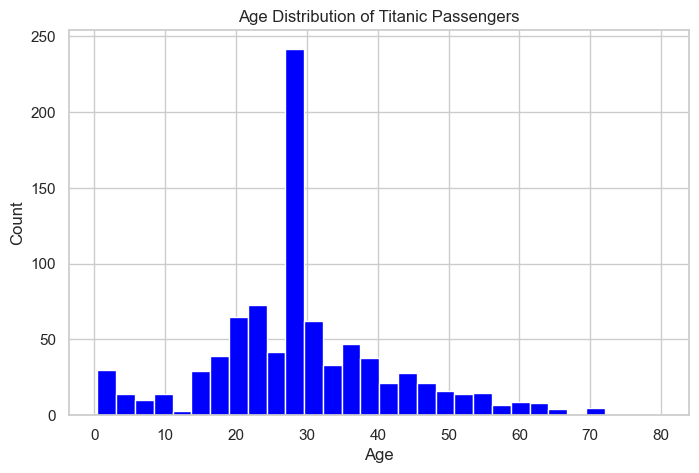

In [8]:
# Age distribution of passengers
plt.figure(figsize=(8,5)) # Set the figure size for better visualization
plt.hist(df['Age'], bins=30, color='blue') # Create a histogram to visualize the age distribution of passengers, using 30 bins and blue color for better visibility
plt.title("Age Distribution of Titanic Passengers") # Set the title of the plot to describe what it represents
plt.xlabel("Age") # Set the label for the x-axis to indicate that it represents age
plt.ylabel("Count") # Set the label for the y-axis to indicate that it represents the count of passengers in each age group
plt.show() # Display the plot to visualize the age distribution of passengers

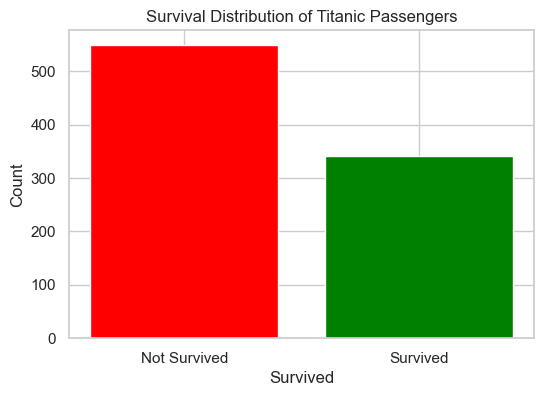

In [9]:
# Survival
survival_counts = df['Survived'].value_counts() # Count the number of survivors and non-survivors in the 'Survived' column
plt.figure(figsize=(6,4)) # Set the figure size for better visualization
plt.bar(survival_counts.index, survival_counts.values, color=['red', 'green']) # Create a bar chart to visualize the survival counts
plt.title("Survival Distribution of Titanic Passengers") # Set the title of the plot to describe what it represents
plt.xlabel("Survived") # Set the label for the x-axis to indicate that it represents survival status
plt.ylabel("Count") # Set the label for the y-axis to indicate that it represents the count of passengers
plt.xticks(survival_counts.index, ['Not Survived', 'Survived']) # Set the x-axis ticks to represent the categories
plt.show() # Display the plot to visualize the survival distribution of passengers

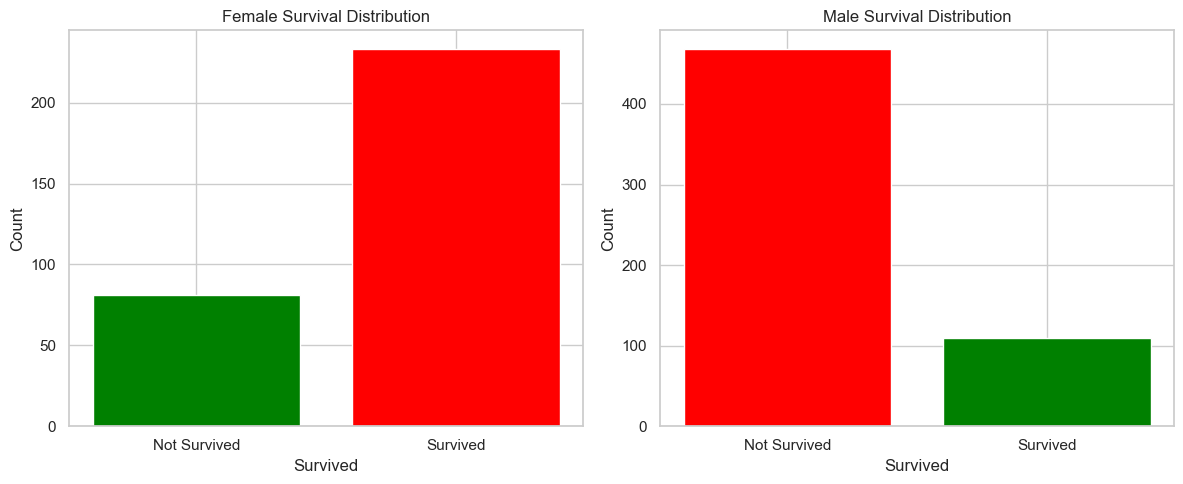

In [10]:
femalesurvival_counts = df[df['Sex'] == 'female']['Survived'].value_counts() # Count the number of survivors and non-survivors among females
malesurvival_counts = df[df['Sex'] == 'male']['Survived'].value_counts() # Count the number of survivors and non-survivors among males
plt.figure(figsize=(12,5)) # Set the figure size for better visualization
plt.subplot(1, 2, 1) # Create a subplot for female survival distribution
plt.bar(femalesurvival_counts.index, femalesurvival_counts.values, color=['red', 'green']) # Create a bar chart to visualize the survival counts for females
plt.xlabel('Survived')
plt.ylabel('Count')
plt.title('Female Survival Distribution')
plt.xticks([0, 1], ['Not Survived', 'Survived'])

plt.subplot(1, 2, 2) # Create a subplot for male survival distribution
plt.bar(malesurvival_counts.index, malesurvival_counts.values, color=['red', 'green']) # Create a bar chart to visualize the survival counts for males
plt.xlabel('Survived')
plt.ylabel('Count')
plt.title('Male Survival Distribution')
plt.xticks([0, 1], ['Not Survived', 'Survived'])
plt.tight_layout() # Adjust the layout to prevent overlap between subplots
plt.show() # Display the plots to visualize the survival distribution for both genders

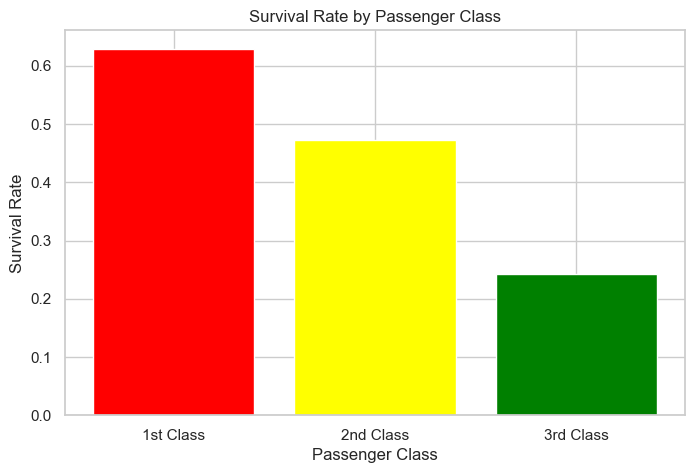

In [11]:
survival_by_class = df.groupby('Pclass')['Survived'].mean() # Calculate the mean survival rate for each passenger class
plt.figure(figsize=(8,5)) # Set the figure size for better visualization        
plt.bar(survival_by_class.index, survival_by_class.values, color=['red', 'yellow', 'green']) # Create a bar chart to visualize the survival rates by passenger class
plt.title("Survival Rate by Passenger Class") # Set the title of the plot to describe what it represents    
plt.xlabel("Passenger Class") # Set the label for the x-axis to indicate that it represents passenger class
plt.ylabel("Survival Rate") # Set the label for the y-axis to indicate that it represents the survival rate
plt.xticks(survival_by_class.index, ['1st Class', '2nd Class', '3rd Class']) # Set the x-axis ticks to represent the passenger classes
plt.show() # Display the plot to visualize the survival rates by passenger class

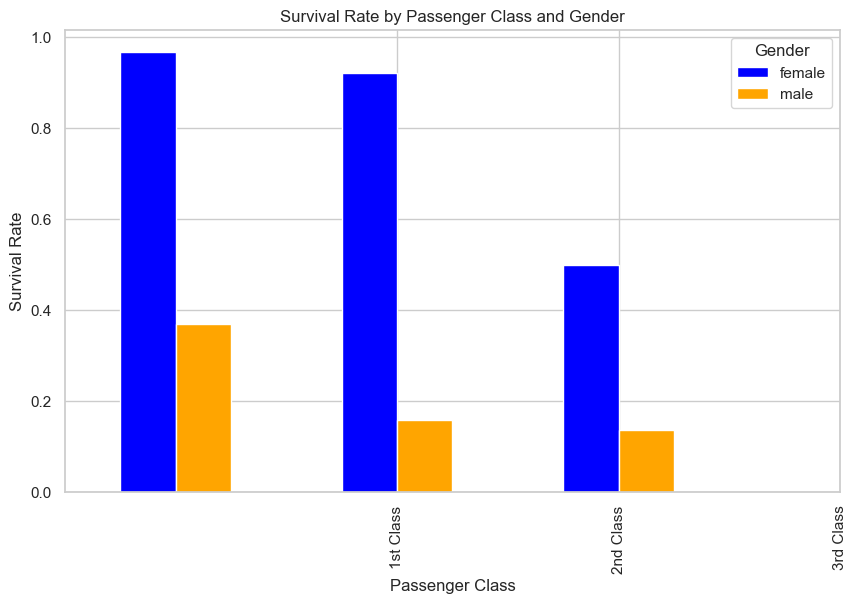

In [12]:
survival_by_gender_class = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack() # Calculate the mean survival rate for each combination of passenger class and gender, and reshape the data for plotting
survival_by_gender_class.plot(kind='bar', figsize=(10,6), color=['blue', 'orange']) # Create a bar chart to visualize the survival rates by passenger class and gender
plt.title("Survival Rate by Passenger Class and Gender") # Set the title of the plot to describe what it represents
plt.xlabel("Passenger Class") # Set the label for the x-axis to indicate that it represents passenger class
plt.ylabel("Survival Rate") # Set the label for the y-axis to indicate that it represents the survival rate
plt.legend(title="Gender") # Set the legend title to indicate that it represents gender
plt.xticks(survival_by_gender_class.index, ['1st Class', '2nd Class', '3rd Class']) # Set the x-axis ticks to represent the passenger classes
plt.show() # Display the plot to visualize the survival rates by passenger class and gender

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_31304\2338745879.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_age_group = survival_by_age_group.groupby('AgeGroup')['Survived'].mean() # Calculate the mean survival rate for each age group


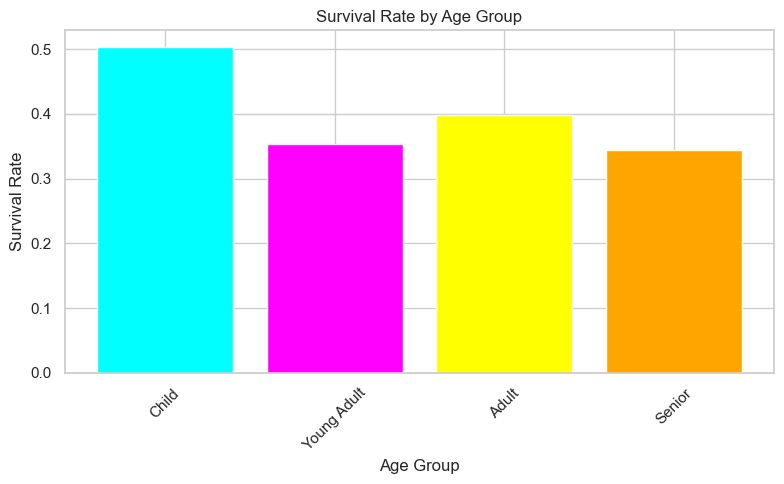

In [13]:
survival_by_age_group = df.copy() # Create a copy of the original DataFrame to avoid modifying it
survival_by_age_group['AgeGroup'] = pd.cut(survival_by_age_group['Age'], bins=[0, 18, 35, 50, 100], labels=['Child', 'Young Adult', 'Adult', 'Senior']) # Create age groups by categorizing the 'Age' column into bins and assigning labels to each age group
survival_by_age_group = survival_by_age_group.groupby('AgeGroup')['Survived'].mean() # Calculate the mean survival rate for each age group
plt.figure(figsize=(8,5)) # Set the figure size for better visualization
plt.bar(survival_by_age_group.index, survival_by_age_group.values, color=['cyan', 'magenta', 'yellow', 'orange']) # Create a bar chart to visualize the survival rates by age group
plt.title("Survival Rate by Age Group") # Set the title of the plot to describe what it represents
plt.xlabel("Age Group") # Set the label for the x-axis to indicate that it represents age groups
plt.ylabel("Survival Rate") # Set the label for the y-axis to indicate that it represents the survival rate
plt.xticks(rotation=45) # Rotate the x-axis ticks for better readability
plt.tight_layout() # Adjust the layout to prevent overlap between subplots
plt.show() # Display the plot to visualize the survival rates by age group

## Univariate Analysis
### Numerical Features

Let's use matplotlib to get a sense of each of our variables independently first. One useful note is that if we have a subplot grid, we typically need to call axes[r, c] to process the graph at row 
 and column. However, by taking axes.flatten(), we can turn the 2d array into a 1d array where the index of the graph is its position if you were reading from the start (
). Other methods/properties referenced:

* .dropna() drops all NA values in a Series and all rows with at least one NA in a dataframe
* ax.hist() creates histograms/frequency distributions
* bins defines the number of separated columns the continuous data is separated into
* axvline creates an infinite vertical line spanning across an Axes plot

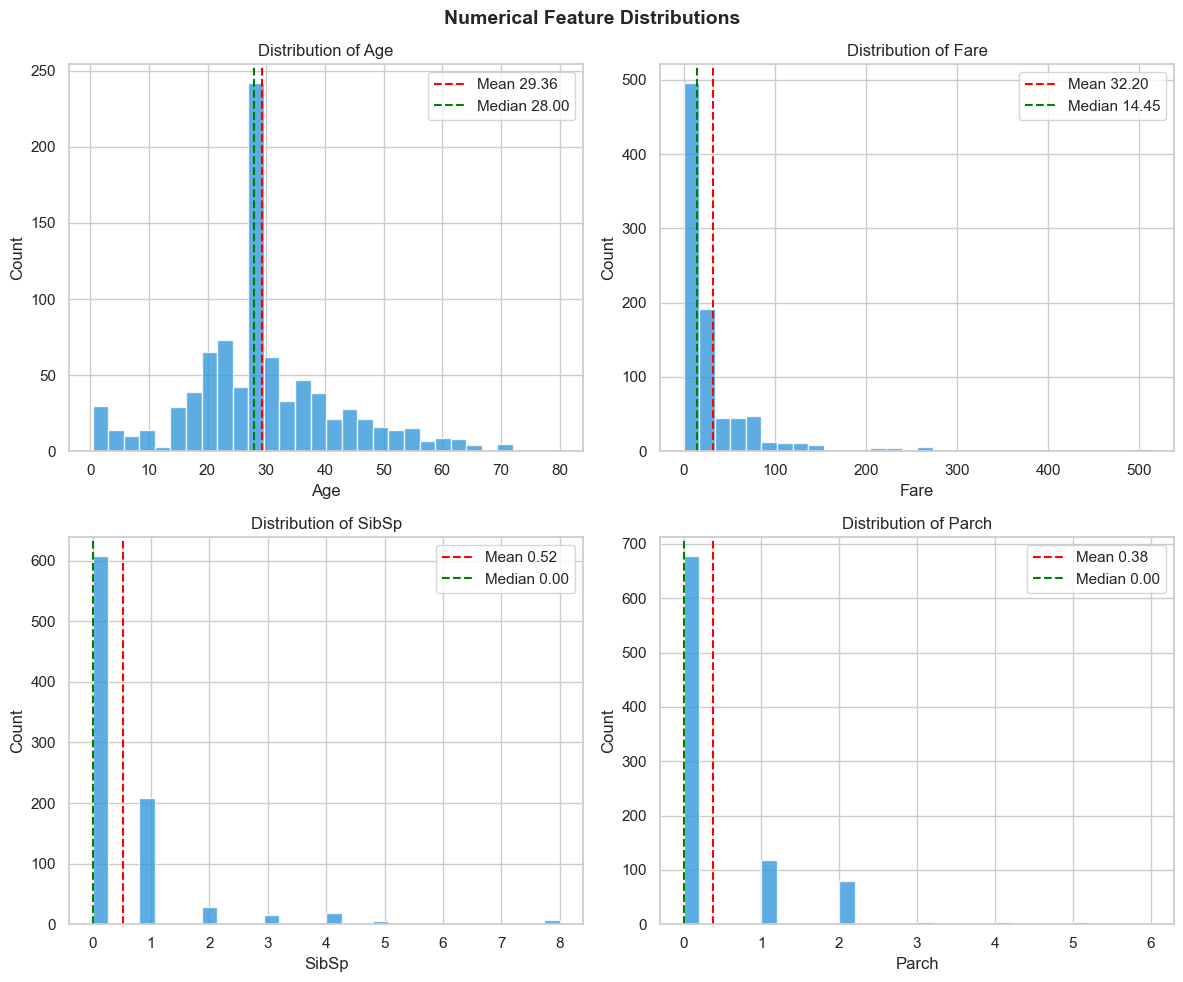

In [14]:
numerical_cols = ["Age", "Fare", "SibSp", "Parch"]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.flatten() # flatten so you can call by the Nth like you're reading

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=30, color="#3498db", edgecolor="white", alpha=0.8) 
    axes[i].set_title("Distribution of " + col)
    axes[i].axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean {df[col].mean():.2f}") #draw mean line
    axes[i].axvline(df[col].median(), color="green", linestyle="--", label=f"Median {df[col].median():.2f}") #draw median line
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].legend()

plt.suptitle("Numerical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

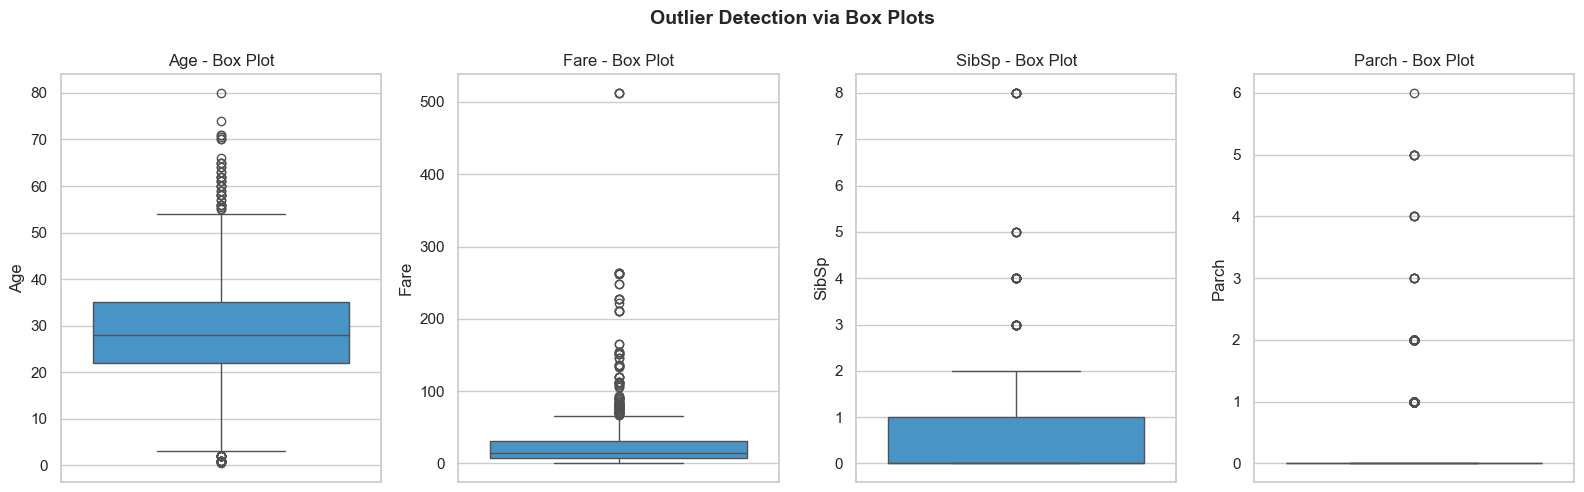

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, col in enumerate(numerical_cols):
    # ----- using basematplotlib -----
    # bplot = axes[i].boxplot(df[col].dropna(), patch_artist=True) 
    # bplot['boxes'][0].set_facecolor("#3498db")
    # axes[i].set_ylabel(col)
    # axes[i].set_title(f"{col} - Box Plot")

    sns.boxplot(data=df[col], ax=axes[i], color="#3498db") #data is generic (defaults to y). Use x for horizontal boxplot.
    axes[i].set_title(f"{col} - Box Plot")

plt.suptitle("Outlier Detection via Box Plots", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

* 38.4% survived, 61.6% did not
* Gender and passenger class had a strong correlation on survival (women had a 74% chance to survive versus 18% for men, and the probability of first class surviving was magnitudes higher than third class).
* People who embarked at C had a much higher chance of surviving likely because there was a greater percentage of 1st class.
* Small families of 2 to 4 had the greatest survival rates.
* 77% of cabin, 20% of age, and 1% of embarked data was missing.

Conclusion: The analysis of the Titanic dataset reveals several key insights into the factors that influenced survival rates. 
The age distribution of passengers shows a wide range of ages, with a significant number of children and young adults. 
The overall survival distribution indicates that a majority of passengers did not survive, 
with a notable difference between genders and passenger classes.
Females had a significantly higher survival rate compared to males, 
which can be attributed to the "women and children first" policy during the evacuation. 
Additionally, passengers in the first class had a much higher survival rate compared to those in the second and third classes, 
likely due to their proximity to lifeboats and better access to safety measures. 
Age also played a role in survival, with children and young adults having higher survival rates compared to adults and seniors. 
These findings highlight the importance of social and economic factors in determining survival outcomes during the Titanic disaster.